In [13]:
import sys
print("Python:", sys.version.split()[0])
print("Exécutable:", sys.executable)   # doit contenir venv-pneumonia

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import PIL
import cv2
import tensorflow as tf
import kagglehub

print("\n--- Versions ---")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__)
print("TensorFlow:", tf.__version__)
print("GPU détecté:", tf.config.list_physical_devices('GPU'))

Python: 3.12.13
Exécutable: /usr/bin/python3

--- Versions ---
NumPy: 2.0.2
Pandas: 2.2.2
scikit-learn: 1.6.1
OpenCV: 4.13.0
TensorFlow: 2.20.0
GPU détecté: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("OK, données dans :", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
OK, données dans : /kaggle/input/chest-xray-pneumonia


### Data Exploration


In [15]:
import os
BASE_DIR = os.path.join(path, "chest_xray")

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

for nom, d in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    print(nom, "->", os.listdir(d))


TRAIN -> ['PNEUMONIA', 'NORMAL']
VAL -> ['PNEUMONIA', 'NORMAL']
TEST -> ['PNEUMONIA', 'NORMAL']


In [16]:
def compter_images(dossier):
    """
    Compte le nombre d'images dans les sous-dossiers NORMAL et PNEUMONIA.

    Paramètre
    ---------
    dossier : str
        Chemin vers un split (train, val ou test).

    Retour
    ------
    dict : {'NORMAL': int, 'PNEUMONIA': int}
    """
    counts = {}
    for classe in ["NORMAL", "PNEUMONIA"]:
        chemin_classe = os.path.join(dossier, classe)
        counts[classe] = len(os.listdir(chemin_classe))
    return counts

In [17]:
for nom, dossier in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    print(nom, ":", compter_images(dossier))

TRAIN : {'NORMAL': 1341, 'PNEUMONIA': 3875}
VAL : {'NORMAL': 8, 'PNEUMONIA': 8}
TEST : {'NORMAL': 234, 'PNEUMONIA': 390}


#### La repartition de TRAIN est vraiment déséquilibré. Il faudra alors tirer attention sur l'accuracy qui ne sera pas le miroir de la réalité et sera trompeuse .
#### De plus, la partie VAL est ridiculement petit, par rapport au TRAIN. On va alors re-split pour que la distribution soit cohérente.



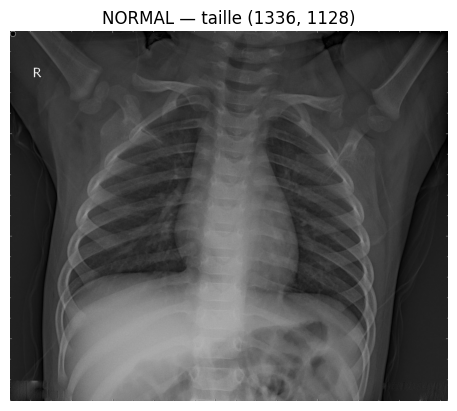

(1336, 1128)

In [18]:
import matplotlib.pyplot as plt
from PIL import Image

def afficher_exemple(split_dir, classe):
    """
    Affiche la première image d'une classe donnée.

    Paramètres
    ----------
    split_dir : str
        Chemin d'un split (ex. TRAIN_DIR).
    classe : str
        "NORMAL" ou "PNEUMONIA".
    """
    # 1. Chemin du dossier de la classe
    chemin_classe = os.path.join(split_dir, classe)

    # 2. Liste des fichiers, on prend le premier
    fichiers = os.listdir(chemin_classe)
    premier_fichier = fichiers[0]   # le [0] = premier élément de la liste

    # 3. Chemin complet de l'image
    # TODO : assemble chemin_classe + premier_fichier avec os.path.join
    chemin_image = os.path.join(chemin_classe, premier_fichier)

    # 4. Ouvre l'image avec PIL
    img = Image.open(chemin_image)

    # 5. Affiche
    plt.imshow(img, cmap="gray")          # cmap="gray" car ce sont des radios N&B
    plt.title(f"{classe} — taille {img.size}")   # img.size = (largeur, hauteur)
    plt.axis("off")
    plt.show()

    # On retourne la taille pour info
    return img.size

# Appel : affiche une image NORMAL du train
# TODO : appelle afficher_exemple avec TRAIN_DIR et "NORMAL"
afficher_exemple(TRAIN_DIR, "NORMAL")

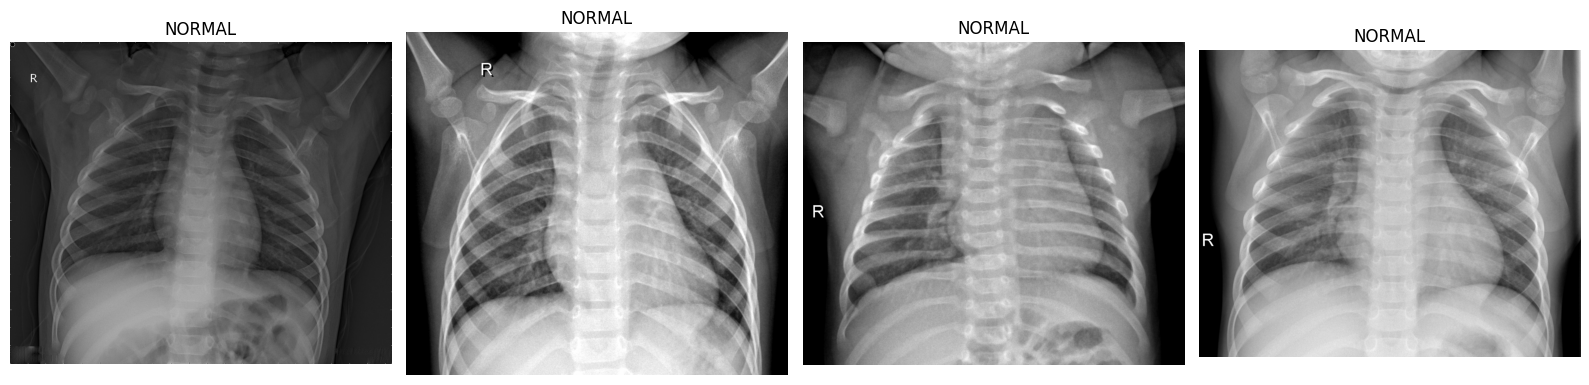

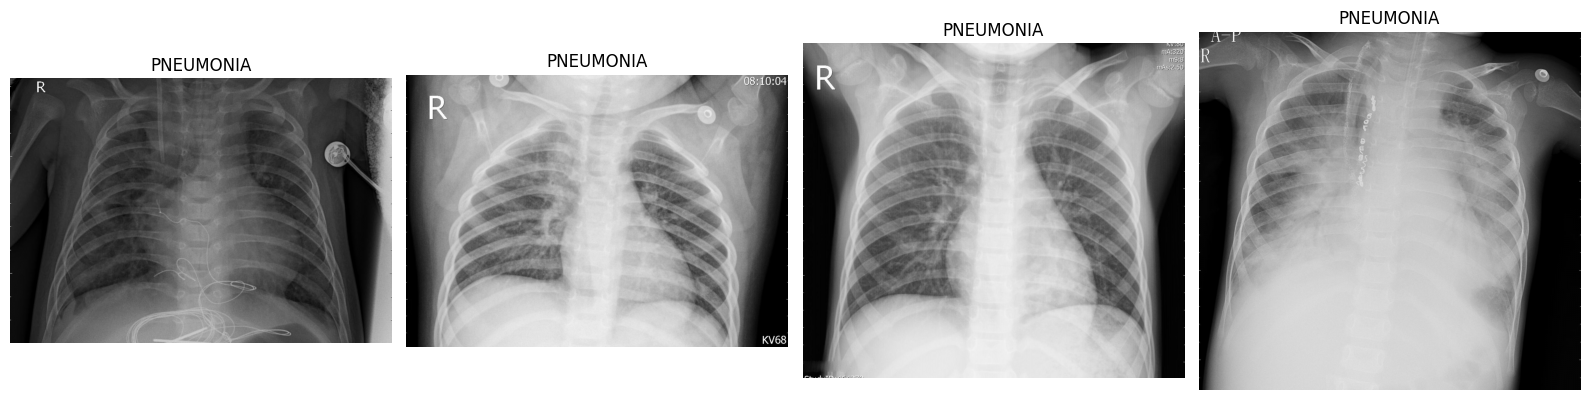

In [19]:
def afficher_grille(split_dir, classe, n=4):
    """
    Affiche les n premières images d'une classe sur une ligne.

    Paramètres
    ----------
    split_dir : str   -> chemin d'un split (ex. TRAIN_DIR)
    classe    : str   -> "NORMAL" ou "PNEUMONIA"
    n         : int   -> nombre d'images à afficher (défaut 4)
    """
    chemin_classe = os.path.join(split_dir, classe)
    fichiers = os.listdir(chemin_classe)[:n]   # [:n] = les n premiers fichiers

    # Crée une figure avec n sous-graphiques côte à côte
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    for i, fichier in enumerate(fichiers):
        chemin_image = os.path.join(chemin_classe, fichier)
        img = Image.open(chemin_image)
        axes[i].imshow(img, cmap="gray")          # cmap="gray" car ce sont des radios N&B
        axes[i].set_title(f"{classe}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Compare les deux classes
afficher_grille(TRAIN_DIR, "NORMAL", n=4)
afficher_grille(TRAIN_DIR, "PNEUMONIA", n=4)

#### La fonction ci-dessus affiche la difference entre 4 radio normales et 4 radio avec présence de pneumonie, afin de comparer visuallement ces deux ensemble de radio.

#### L'inspection visuelle ne permet pas de distinguer aisément les deux classes pour un œil non expert, ce qui justifie l'approche par apprentissage automatique et souligne l'importance de l'interprétabilité (Grad-CAM) pour valider que le modèle s'appuie sur des régions cliniquement pertinentes.

In [20]:
import numpy as np

def collecter_tailles(split_dir, n_par_classe=150):
    """
    Récupère les dimensions (largeur, hauteur) d'un échantillon d'images.

    Paramètres
    ----------
    split_dir    : str -> chemin d'un split (ex. TRAIN_DIR)
    n_par_classe : int -> nb d'images à inspecter par classe

    Retour
    ------
    largeurs, hauteurs : deux listes de nombres
    """
    largeurs = []
    hauteurs = []

    for classe in ["NORMAL", "PNEUMONIA"]:
        chemin_classe = os.path.join(split_dir, classe)
        fichiers = os.listdir(chemin_classe)[:n_par_classe]

        for fichier in fichiers:
            chemin_image = os.path.join(chemin_classe, fichier)
            img = Image.open(chemin_image)
            largeur, hauteur = img.size
            largeurs.append(largeur)
            hauteurs.append(hauteur)
    return largeurs, hauteurs

largeurs, hauteurs = collecter_tailles(TRAIN_DIR)
print("Nombre d'images inspectées :", len(largeurs))
print("Largeur  -> min:", min(largeurs), " max:", max(largeurs), " moyenne:", round(np.mean(largeurs)))
print("Hauteur  -> min:", min(hauteurs), " max:", max(hauteurs), " moyenne:", round(np.mean(hauteurs)))

Nombre d'images inspectées : 300
Largeur  -> min: 428  max: 2633  moyenne: 1430
Hauteur  -> min: 172  max: 2578  moyenne: 1102


#### Un CNN exige des entrées de taille fixe. Les couches denses finales ont un nombre de poids figé, qui dépend de la dimension du vecteur aplati — donc toutes les images doivent arriver avec exactement les mêmes dimensions.
#### Le choix standard pour les modèle pré-entrainés est 224x224 et permet de limiter le coût mémoire, au prix d'une perte de résolution acceptable

In [21]:
import tensorflow as tf

# Hyperparamètres de chargement
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [22]:
# Jeu d'entraînement (le dossier train officiel)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED,
)

# Jeu de test (le dossier test officiel, qu'on garde intact)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    color_mode="rgb",
    shuffle=False,             # pas de mélange pour le test (évaluation stable)
)

# Vérifie les classes détectées
print("Classes :", train_ds.class_names)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Classes : ['NORMAL', 'PNEUMONIA']


#### Le redimensionnement à 224×224 entraîne une perte d'information haute fréquence (textures fines, petits détails). Ce compromis est acceptable pour la détection de pneumonie, dont les marqueurs (opacités étendues) relèvent des basses fréquences préservées par le sous-échantillonnage. Cette limite serait toutefois rédhibitoire pour des pathologies à signes fins (micro-nodules), ce qui restreint la transposabilité du modèle.


### Redimensionnement de TRAIN et VAL

##### On va prendre ~20 % du train pour la validation.

In [23]:
# Nombre total de batches dans train_ds
n_batches = tf.data.experimental.cardinality(train_ds).numpy()
print("Nombre total de batches :", n_batches)

val_fraction = 0.2
n_val_batches = int(n_batches * val_fraction)
print("Batches pour validation :", n_val_batches)
val_ds =  train_ds.take(n_val_batches)

train_final_ds = train_ds.skip(n_val_batches)

print("Batches train  :", tf.data.experimental.cardinality(train_final_ds).numpy())
print("Batches val    :", tf.data.experimental.cardinality(val_ds).numpy())

Nombre total de batches : 163
Batches pour validation : 32
Batches train  : 131
Batches val    : 32


In [24]:
def compter_labels(dataset):
    compte = {0: 0, 1: 0}
    for _, labels in dataset:
        labels = labels.numpy().flatten()
        compte[0] += int(np.sum(labels == 0))
        compte[1] += int(np.sum(labels == 1))
    return compte

comptes = compter_labels(train_final_ds)
print("TRAIN final :", comptes)

TRAIN final : {0: 1059, 1: 3133}


In [25]:
n_normal, n_pneumonia = comptes[0], comptes[1]
n_total = n_normal + n_pneumonia
class_weights = {
    0: n_total / (2 * n_normal),
    1: n_total / (2 * n_pneumonia),
}
print("class_weights :", class_weights)

class_weights : {0: 1.9792256846081209, 1: 0.6690073412065113}


In [26]:
AUTOTUNE = tf.data.AUTOTUNE
train_final_ds = train_final_ds.cache().prefetch(AUTOTUNE)
val_ds         = val_ds.cache().prefetch(AUTOTUNE)
test_ds        = test_ds.cache().prefetch(AUTOTUNE)
print("Pipeline optimisé ✓")

Pipeline optimisé ✓


In [27]:
def construire_baseline(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

model = construire_baseline()
model.summary()

NameError: name 'models' is not defined

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)
print("Modèle compilé ✓")

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint("baseline.keras", monitor="val_loss", save_best_only=True),
]

history = model.fit(
    train_final_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
)